# Aqua: Legionella Risk Early Warning  

#### INSTALL & IMPORT NECESSARY LIBRARIES.

In [1]:
pip install jupyter pandas numpy scikit-learn matplotlib joblib shap python-dotenv ucimlrepo pdfplumber langchain langchain-community chromadb sentence-transformers tiktoken openai seaborn shap --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.5 MB/s eta 0:00:00 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 5.7 MB/s eta 0:00:00
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.4 MB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.7/109.7 kB 3.5 MB/s eta 0:00:00? eta -:--:--
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.7 MB/s eta 0:00:00
  Using cached PyPika-0.48.9.tar.gz (67 kB)
  Installing build dependencies ... do

In [119]:
import os, sys, math, json, hashlib, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from sklearn.preprocessing import LabelEncoder
import shap

# RAG deps
import pdfplumber
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from langchain.docstore.document import Document
from langchain.chat_models import ChatOpenAI
from langchain.chains import RetrievalQA

#setting display settings for the plots.
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

#### LOADING IN THE DATA

In [95]:
# loading the CSV
df = pd.read_csv("aquadataa.csv", parse_dates=["timestamp"]) # as timestap to enable time-series operations

# view the data
df.head()

,station_id,timestamp,temperature_c,ph,turbidity_ntu,conductivity_uscm,flow_rate_lpm,free_chlorine_mgL
0,STN001,2024-01-08 00:00:00,18.264024,6.863384,2.953592,465.141719,0.5,0.299014
1,STN001,2024-01-08 00:15:00,10.078147,6.970293,2.247043,438.531246,0.5,0.219156
2,STN001,2024-01-08 00:30:00,14.933028,7.214343,2.865927,489.046463,0.5,0.812067
3,STN001,2024-01-08 00:45:00,14.273124,7.035853,6.717760,550.238641,1.0,0.224027
4,STN001,2024-01-08 01:00:00,3.077457,7.129741,0.816345,402.432727,2.0,0.292570


The units of each element in the dataset are below 
###### Temperature → °C (degrees Celsius) _[The thermal state of the water.]_

###### ph → no unit (logarithmic scale of hydrogen ion concentration) _[How acidic or alkaline the water is.]_

###### Turbidity → NTU (Nephelometric Turbidity Units) _[The cloudiness or haziness of a fluid caused by large numbers of individual particles that are generally invisible to the naked eye]_

###### Conductivity → µS/cm (microsiemens per centimetre) — measure of ionic content _[The conductivity of water is its ability to conduct electricity, which is determined by the concentration of dissolved charged ions (salts) and is influenced by temperature]_

###### Flow_rate → L/min (litres per minute) _[The volumetric flow of water]_

###### Free_chlorine_mgL → mg/L (milligrams per litre) _[Concentration of chlorine available as a disinfectant (not yet bound to contaminants)]_

#### EDA

In [96]:
# viewing data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6730 entries, 0 to 6729
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   station_id         6730 non-null   object        
 1   timestamp          6730 non-null   datetime64[ns]
 2   temperature_c      6730 non-null   float64       
 3   ph                 6730 non-null   float64       
 4   turbidity_ntu      6730 non-null   float64       
 5   conductivity_uscm  6730 non-null   float64       
 6   flow_rate_lpm      6730 non-null   float64       
 7   free_chlorine_mgL  6730 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 420.8+ KB


In [97]:
# checking for any missing values
df.isna().sum()

station_id           0
timestamp            0
temperature_c        0
ph                   0
turbidity_ntu        0
conductivity_uscm    0
flow_rate_lpm        0
free_chlorine_mgL    0
dtype: int64

In [98]:
# checking data types of each attribute
df.dtypes

station_id                   object
timestamp            datetime64[ns]
temperature_c               float64
ph                          float64
turbidity_ntu               float64
conductivity_uscm           float64
flow_rate_lpm               float64
free_chlorine_mgL           float64
dtype: object

In [99]:
# checking for duplicate rows
df[df.duplicated()]

,station_id,timestamp,temperature_c,ph,turbidity_ntu,conductivity_uscm,flow_rate_lpm,free_chlorine_mgL


#### CORRELATION OF FEATURES.

In [100]:
# identifying numeric columns and checking for correlation
numeric_cols = [
    'temperature_c', 'ph', 'turbidity_ntu',
    'conductivity_uscm', 'flow_rate_lpm', 'free_chlorine_mgL'
]

# correlation matrix
correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,temperature_c,ph,turbidity_ntu,conductivity_uscm,flow_rate_lpm,free_chlorine_mgL
temperature_c,1.000000,-0.000719,-0.009620,-0.017838,0.002800,0.001204
ph,-0.000719,1.000000,-0.001684,0.013184,0.011506,0.224972
turbidity_ntu,-0.009620,-0.001684,1.000000,0.816259,-0.576545,0.025035
conductivity_uscm,-0.017838,0.013184,0.816259,1.000000,-0.464448,0.036508
flow_rate_lpm,0.002800,0.011506,-0.576545,-0.464448,1.000000,-0.032008
free_chlorine_mgL,0.001204,0.224972,0.025035,0.036508,-0.032008,1.000000


In [101]:
correlation_matrix.style.background_gradient(cmap='coolwarm')

,temperature_c,ph,turbidity_ntu,conductivity_uscm,flow_rate_lpm,free_chlorine_mgL
temperature_c,1.000000,-0.000719,-0.009620,-0.017838,0.002800,0.001204
ph,-0.000719,1.000000,-0.001684,0.013184,0.011506,0.224972
turbidity_ntu,-0.009620,-0.001684,1.000000,0.816259,-0.576545,0.025035
conductivity_uscm,-0.017838,0.013184,0.816259,1.000000,-0.464448,0.036508
flow_rate_lpm,0.002800,0.011506,-0.576545,-0.464448,1.000000,-0.032008
free_chlorine_mgL,0.001204,0.224972,0.025035,0.036508,-0.032008,1.000000


##### WHAT CAN BE GATHERED?

Turbidity and Conductivity have a _strong positive correlation_. (Most positively correlated pair)

💡 Higher turbidity is associated with higher conductivity.

pH and Free chlorine have a _weak positive correlation_.

💡 Slight tendency for higher pH to be linked with more free chlorine.

Turbidity and Flow rate have a _moderate negative correlation_.

💡 Higher flow rates tend to reduce turbidity.

Conductivity and Flow rate have a _moderate negative correlation_.

💡 Faster flow lowers conductivity.


✨ These negative correlatios suggest that higher flow helps keep water clearer and less conductive.

✨ Temperature shows almost no correlation with other variables (values near 0).


<Figure size 2100x1200 with 0 Axes>

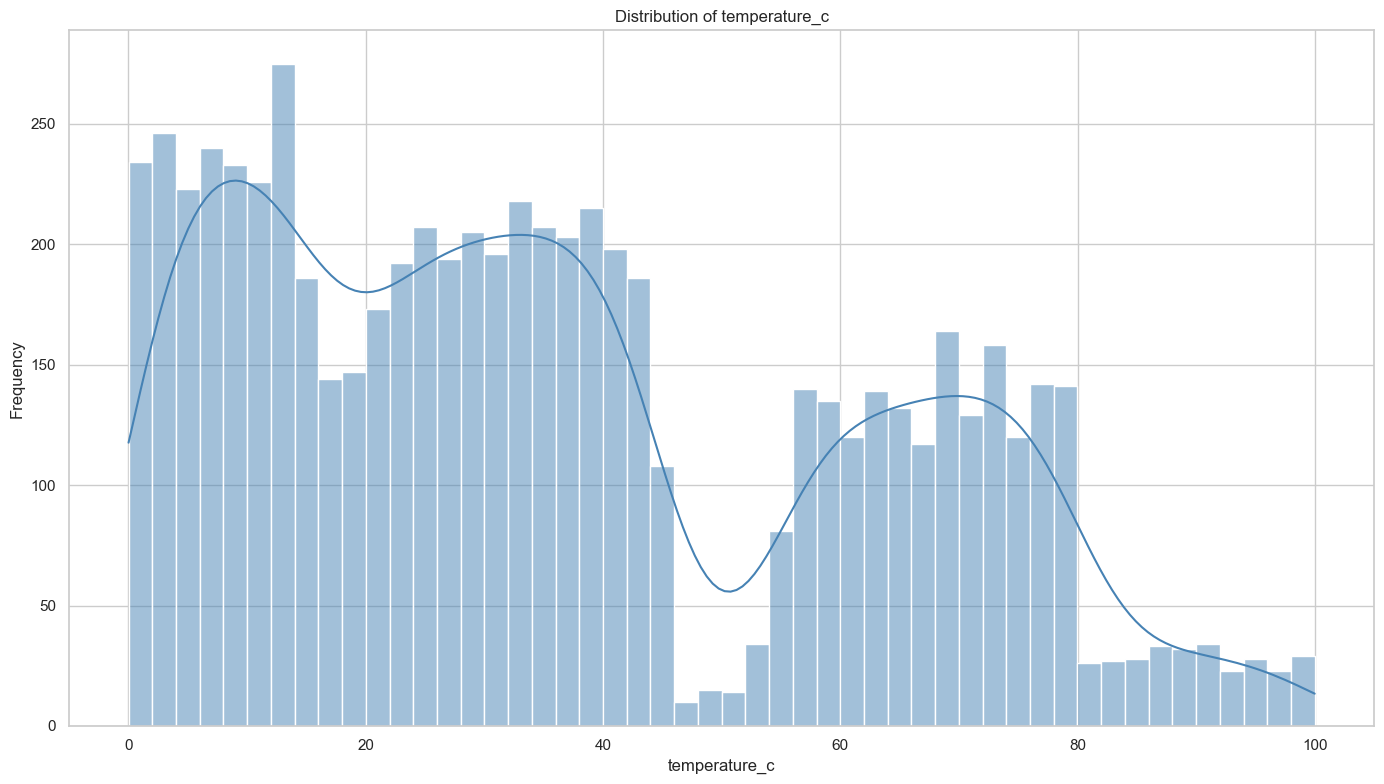

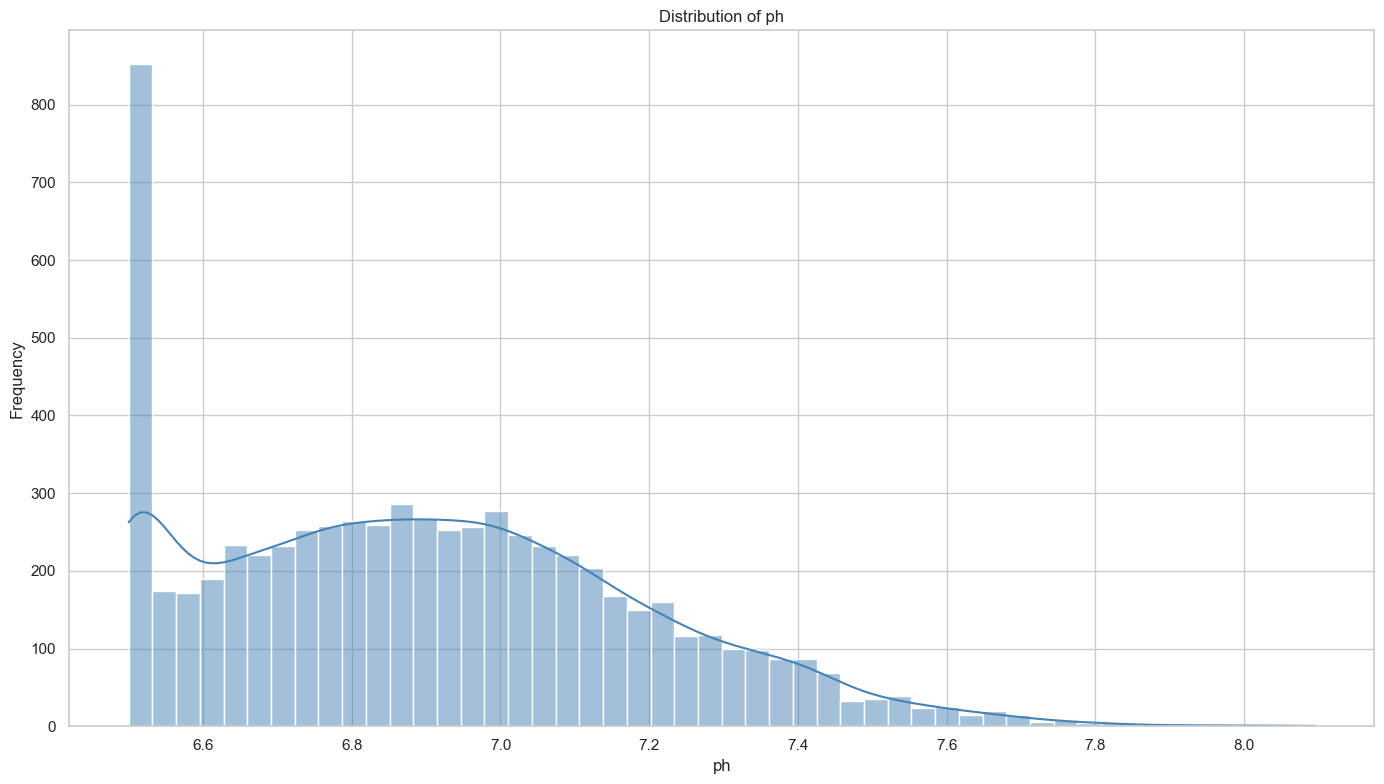

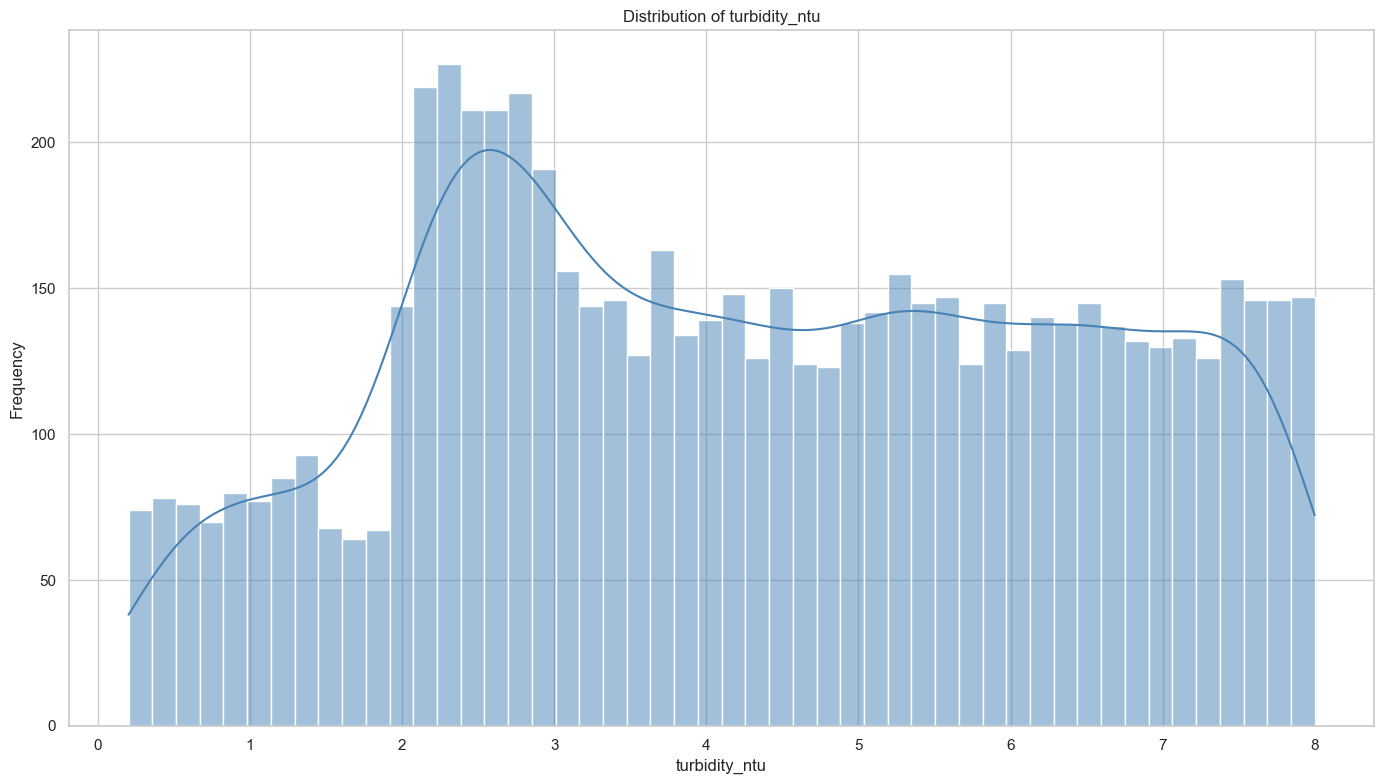

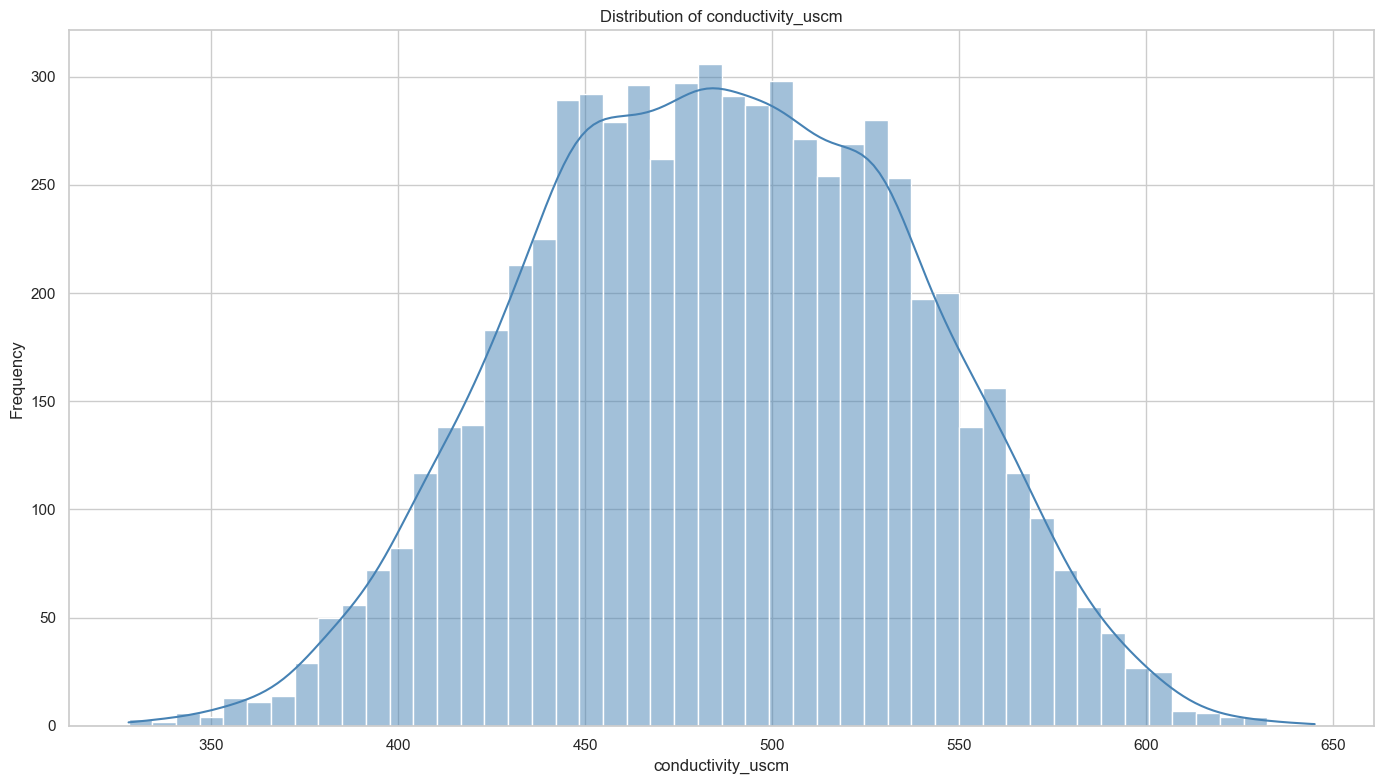

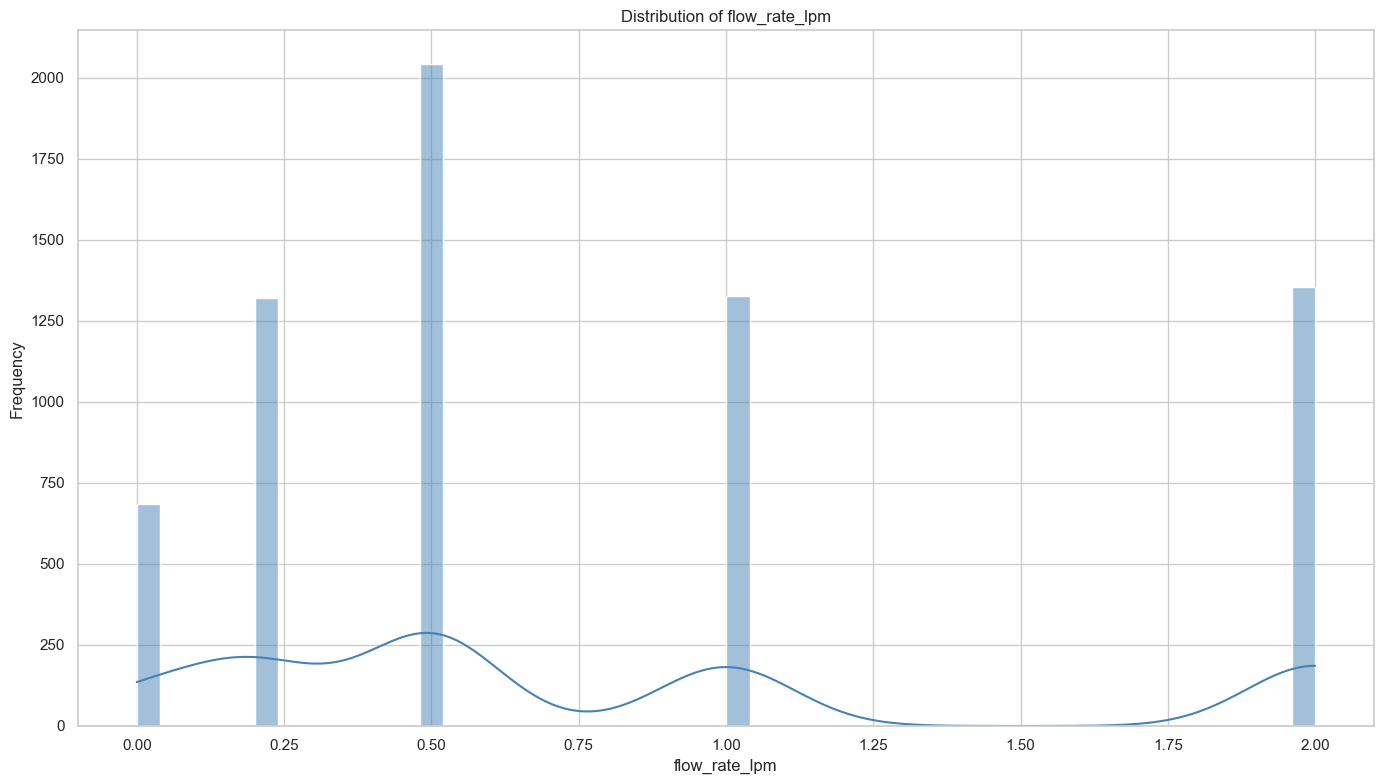

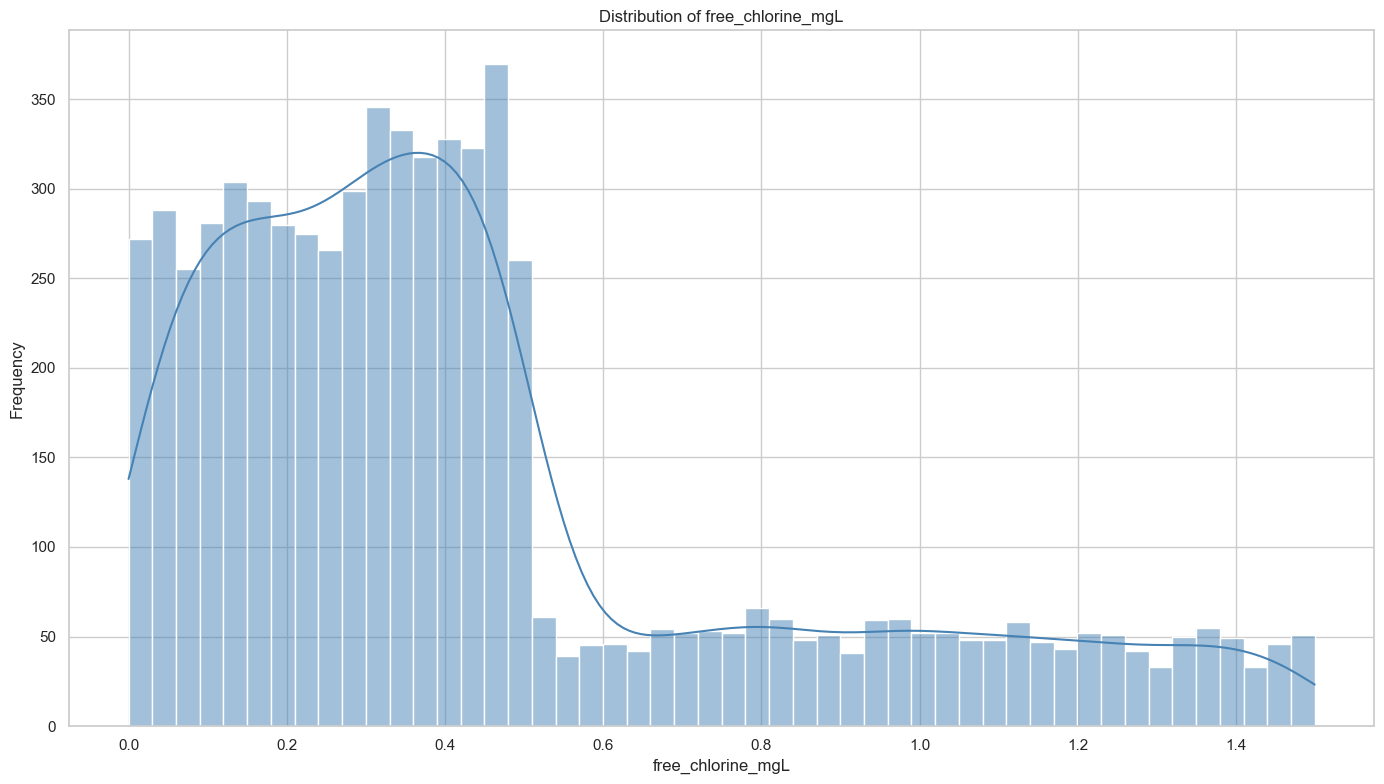

In [102]:
plt.figure(dpi=150) #making the plot sharp and clear

# ploting distribution plots for each numeric feature
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=50, color='steelblue') # using steel blue cause it matches Aquatrust's colours.
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

<Figure size 2100x1200 with 0 Axes>

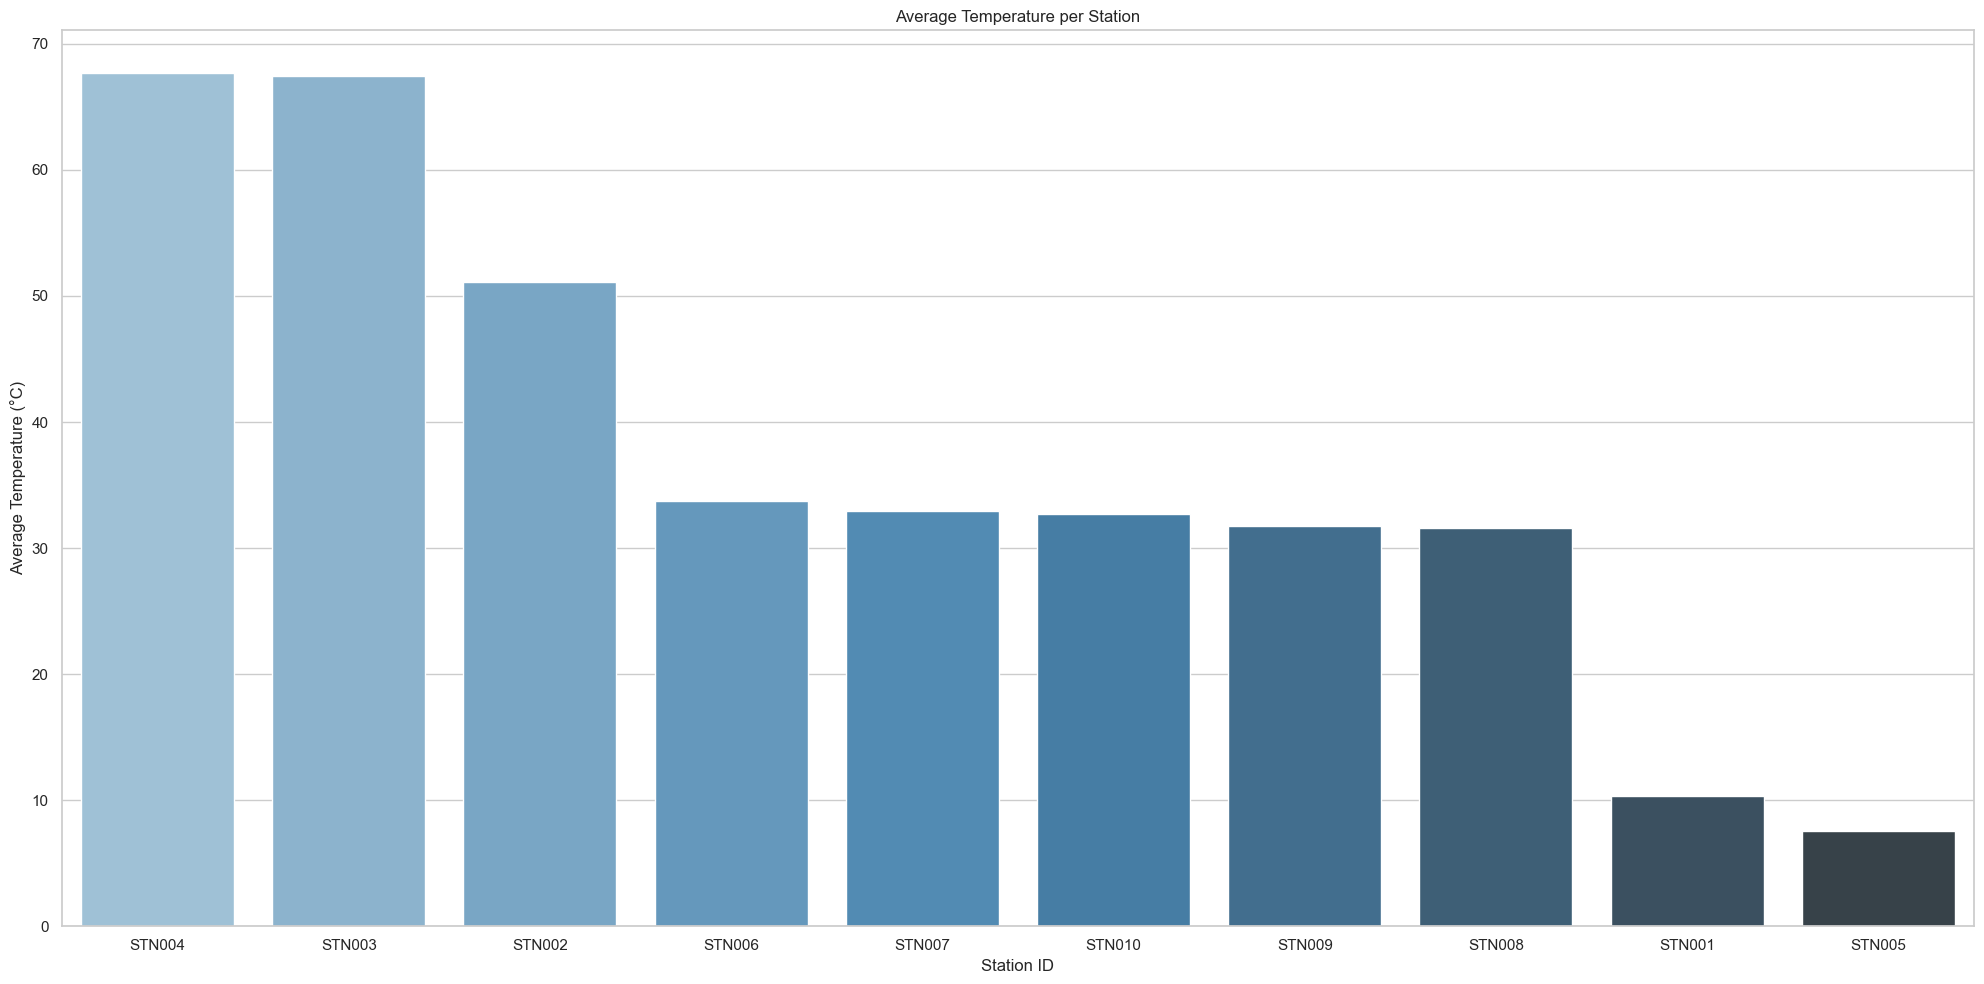

In [103]:
plt.figure(dpi=150) #making the plot sharp and clear

# checkign for average temperature per station
avg_temp = df.groupby('station_id')['temperature_c'].mean().reset_index()

# sorting by temperature
avg_temp = avg_temp.sort_values(by='temperature_c', ascending=False)

# plotting
plt.figure(figsize=(20, 10))
sns.barplot(x='station_id', y='temperature_c', data=avg_temp, palette='Blues_d')

plt.title('Average Temperature per Station')
plt.xlabel('Station ID')
plt.ylabel('Average Temperature (°C)')
plt.tight_layout()
plt.show()

#### K-MEANS CLUSTERING TO VIEW

In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting relevant sensor features
features = ['temperature_c', 'ph', 'free_chlorine_mgL', 'flow_rate_lpm']
X = df[features].copy()

# Standardizing the features (important for distance-based models like KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [81]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [82]:
# Creating a DataFrame to examine cluster centers
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)
cluster_centers['cluster'] = cluster_centers.index

# Displaying the cluster centers to interpret them
cluster_centers

,temperature_c,ph,free_chlorine_mgL,flow_rate_lpm,cluster
0,32.305301,6.885838,0.344525,2.000000,0
1,32.676875,6.831704,0.273625,0.483027,1
2,31.266975,7.105014,0.991197,0.604686,2


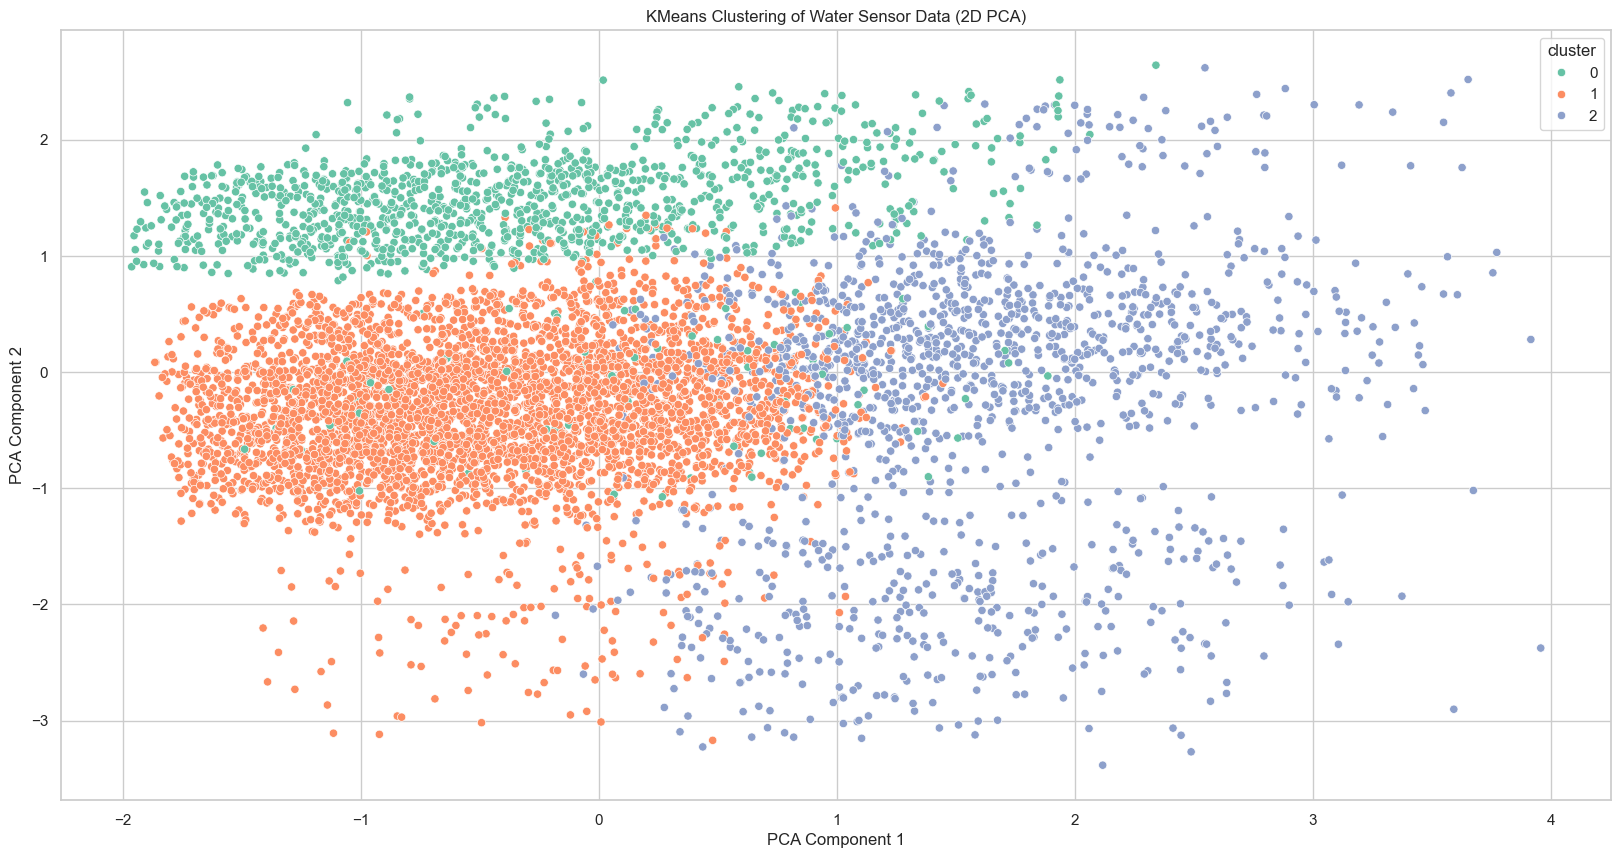

In [84]:
# Applying PCA to reduce dimensionality for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Creating a plot of clusters in 2D space
plt.figure(figsize=(20, 10))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='Set2')
plt.title("KMeans Clustering of Water Sensor Data (2D PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

#### ADDING RISK SCORES AND LABELS
 USING WHO/WATER REGULATION RULES.

In [104]:
# defining risk calculation logic using expert thresholds
def calculate_risk(row):
    # starting with zero risk
    risk_points = 0

    # checking for risky temperature range (20–45°C)
    if 20 <= row['temperature_c'] <= 45:
        risk_points += 1

    # checking for low free chlorine levels
    if row['free_chlorine_mgL'] < 0.2:
        risk_points += 1

    # checking for zero flow rate (stagnation)
    if row['flow_rate_lpm'] == 0:
        risk_points += 1

    return risk_points

# applying risk scoring logic to the dataset
df['risk_score'] = df.apply(calculate_risk, axis=1)

In [105]:
df.head()

,station_id,timestamp,temperature_c,ph,turbidity_ntu,conductivity_uscm,flow_rate_lpm,free_chlorine_mgL,risk_score
0,STN001,2024-01-08 00:00:00,18.264024,6.863384,2.953592,465.141719,0.5,0.299014,0
1,STN001,2024-01-08 00:15:00,10.078147,6.970293,2.247043,438.531246,0.5,0.219156,0
2,STN001,2024-01-08 00:30:00,14.933028,7.214343,2.865927,489.046463,0.5,0.812067,0
3,STN001,2024-01-08 00:45:00,14.273124,7.035853,6.717760,550.238641,1.0,0.224027,0
4,STN001,2024-01-08 01:00:00,3.077457,7.129741,0.816345,402.432727,2.0,0.292570,0


In [109]:
# creating a function to assign risk bands based on total score
def assign_risk_band(score):
    if score == 3:
        return 'High'
    elif score == 2:
        return 'Medium'
    else:
        return 'Low'

# applying the risk band logic to the dataset
df['risk_band'] = df['risk_score'].apply(assign_risk_band)
df.head(10)

,station_id,timestamp,temperature_c,ph,turbidity_ntu,conductivity_uscm,flow_rate_lpm,free_chlorine_mgL,risk_score,risk_band
0,STN001,2024-01-08 00:00:00,18.264024,6.863384,2.953592,465.141719,0.5,0.299014,0,Low
1,STN001,2024-01-08 00:15:00,10.078147,6.970293,2.247043,438.531246,0.5,0.219156,0,Low
2,STN001,2024-01-08 00:30:00,14.933028,7.214343,2.865927,489.046463,0.5,0.812067,0,Low
3,STN001,2024-01-08 00:45:00,14.273124,7.035853,6.717760,550.238641,1.0,0.224027,0,Low
4,STN001,2024-01-08 01:00:00,3.077457,7.129741,0.816345,402.432727,2.0,0.292570,0,Low
5,STN001,2024-01-08 01:15:00,0.158230,6.746156,5.904395,490.278694,0.5,0.043219,1,Low
6,STN001,2024-01-08 01:30:00,16.163596,7.011365,2.667673,459.249593,2.0,0.487457,0,Low
7,STN001,2024-01-08 01:45:00,3.198273,6.746971,6.188117,498.255285,0.5,0.202032,0,Low
8,STN001,2024-01-08 02:00:00,18.822959,7.070899,2.681201,498.793907,0.2,0.157637,1,Low
9,STN001,2024-01-08 02:15:00,3.429702,6.574516,2.730566,401.038248,0.0,0.467618,1,Low


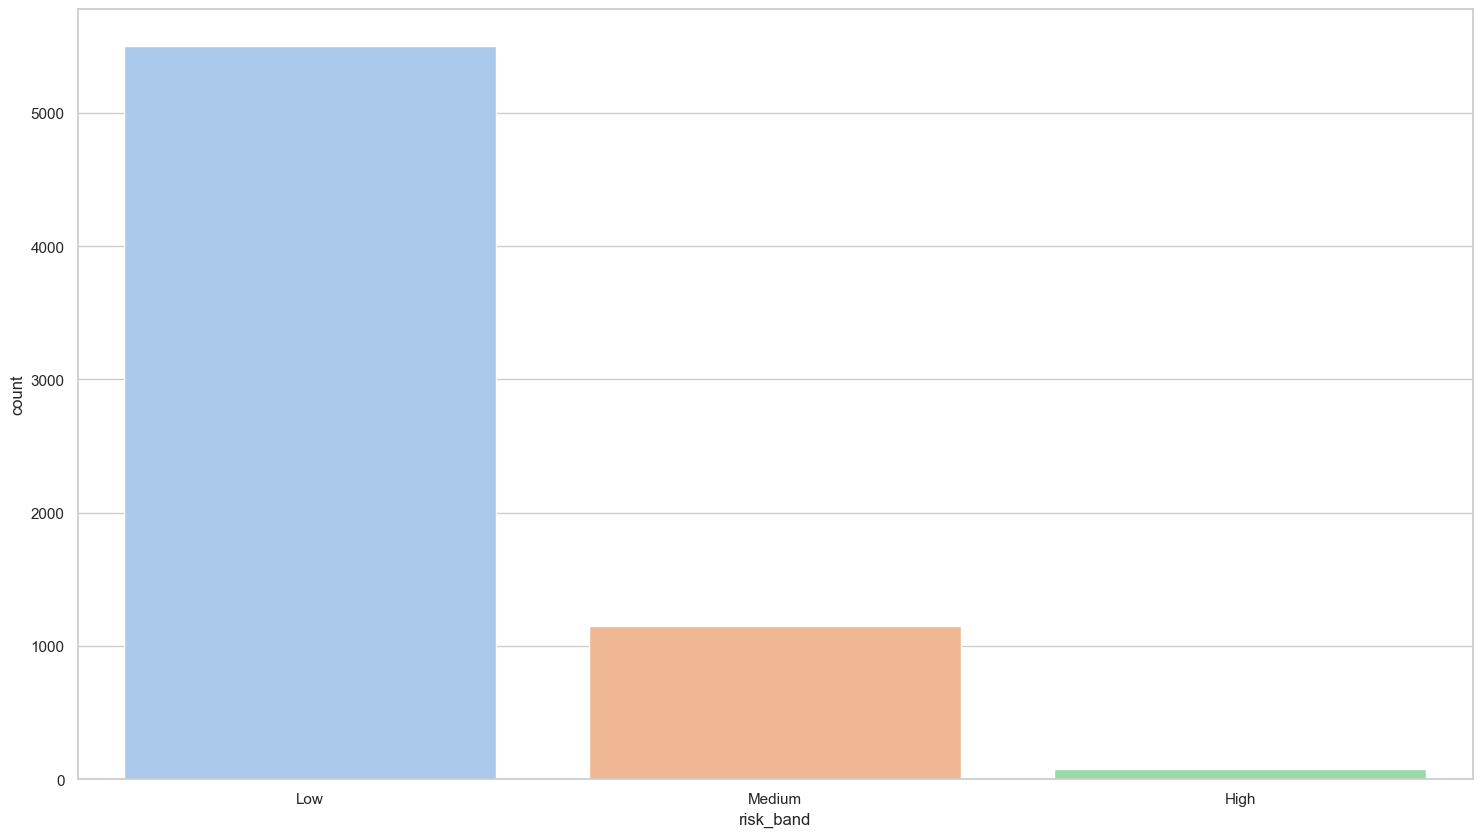

In [107]:
# visualising the rick bands

plt.figure(figsize = (18, 10))
sns.set_palette("pastel") #setting color and hue for differently colored bars, so we can observe the segments more easily.
sns.countplot(x=df['risk_band'], hue=df['risk_band'])

plt.show()

ASSIGNING MORE WEIGHT TO MORE IMPORTANT ASPECTS FOR THE RISK SCORE

In [110]:
# defining risk calculation logic using expert thresholds
def calculate_weighted_risk(row):
    # starting with zero risk
    risk_points = 0

    # checking for risky temperature range (20–45°C)
    if 20 <= row['temperature_c'] <= 45:
        risk_points += 3 #assigning a score of 3 because this is the most important factor, ewspecially in domestic cases (https://www.hse.gov.uk/legionnaires/legionella-landlords-responsibilities.htm)

    # checking for low free chlorine levels
    if row['free_chlorine_mgL'] < 0.2:
        risk_points += 1

    # checking for zero flow rate (stagnation)
    if row['flow_rate_lpm'] == 0:
        risk_points += 2 # stagnation plays a big role as well, most likely more than chlorine in this particular dataset

    return risk_points

# applying risk scoring logic to the dataset
df['weighted_risk_score'] = df.apply(calculate_weighted_risk, axis=1)

In [111]:
df.head(10)

,station_id,timestamp,temperature_c,ph,turbidity_ntu,conductivity_uscm,flow_rate_lpm,free_chlorine_mgL,risk_score,risk_band,weighted_risk_score
0,STN001,2024-01-08 00:00:00,18.264024,6.863384,2.953592,465.141719,0.5,0.299014,0,Low,0
1,STN001,2024-01-08 00:15:00,10.078147,6.970293,2.247043,438.531246,0.5,0.219156,0,Low,0
2,STN001,2024-01-08 00:30:00,14.933028,7.214343,2.865927,489.046463,0.5,0.812067,0,Low,0
3,STN001,2024-01-08 00:45:00,14.273124,7.035853,6.717760,550.238641,1.0,0.224027,0,Low,0
4,STN001,2024-01-08 01:00:00,3.077457,7.129741,0.816345,402.432727,2.0,0.292570,0,Low,0
5,STN001,2024-01-08 01:15:00,0.158230,6.746156,5.904395,490.278694,0.5,0.043219,1,Low,1
6,STN001,2024-01-08 01:30:00,16.163596,7.011365,2.667673,459.249593,2.0,0.487457,0,Low,0
7,STN001,2024-01-08 01:45:00,3.198273,6.746971,6.188117,498.255285,0.5,0.202032,0,Low,0
8,STN001,2024-01-08 02:00:00,18.822959,7.070899,2.681201,498.793907,0.2,0.157637,1,Low,1
9,STN001,2024-01-08 02:15:00,3.429702,6.574516,2.730566,401.038248,0.0,0.467618,1,Low,2


In [112]:
# defining new risk bands based on severity scores
def assign_weighted_risk_band(score):
    if score >= 5:
        return 'High'
    elif score >= 3:
        return 'Medium'
    else:
        return 'Low'

# Applying new risk band logic
df['weighted_risk_band'] = df['weighted_risk_score'].apply(assign_weighted_risk_band)

df.head()

,station_id,timestamp,temperature_c,ph,turbidity_ntu,conductivity_uscm,flow_rate_lpm,free_chlorine_mgL,risk_score,risk_band,weighted_risk_score,weighted_risk_band
0,STN001,2024-01-08 00:00:00,18.264024,6.863384,2.953592,465.141719,0.5,0.299014,0,Low,0,Low
1,STN001,2024-01-08 00:15:00,10.078147,6.970293,2.247043,438.531246,0.5,0.219156,0,Low,0,Low
2,STN001,2024-01-08 00:30:00,14.933028,7.214343,2.865927,489.046463,0.5,0.812067,0,Low,0,Low
3,STN001,2024-01-08 00:45:00,14.273124,7.035853,6.717760,550.238641,1.0,0.224027,0,Low,0,Low
4,STN001,2024-01-08 01:00:00,3.077457,7.129741,0.816345,402.432727,2.0,0.292570,0,Low,0,Low


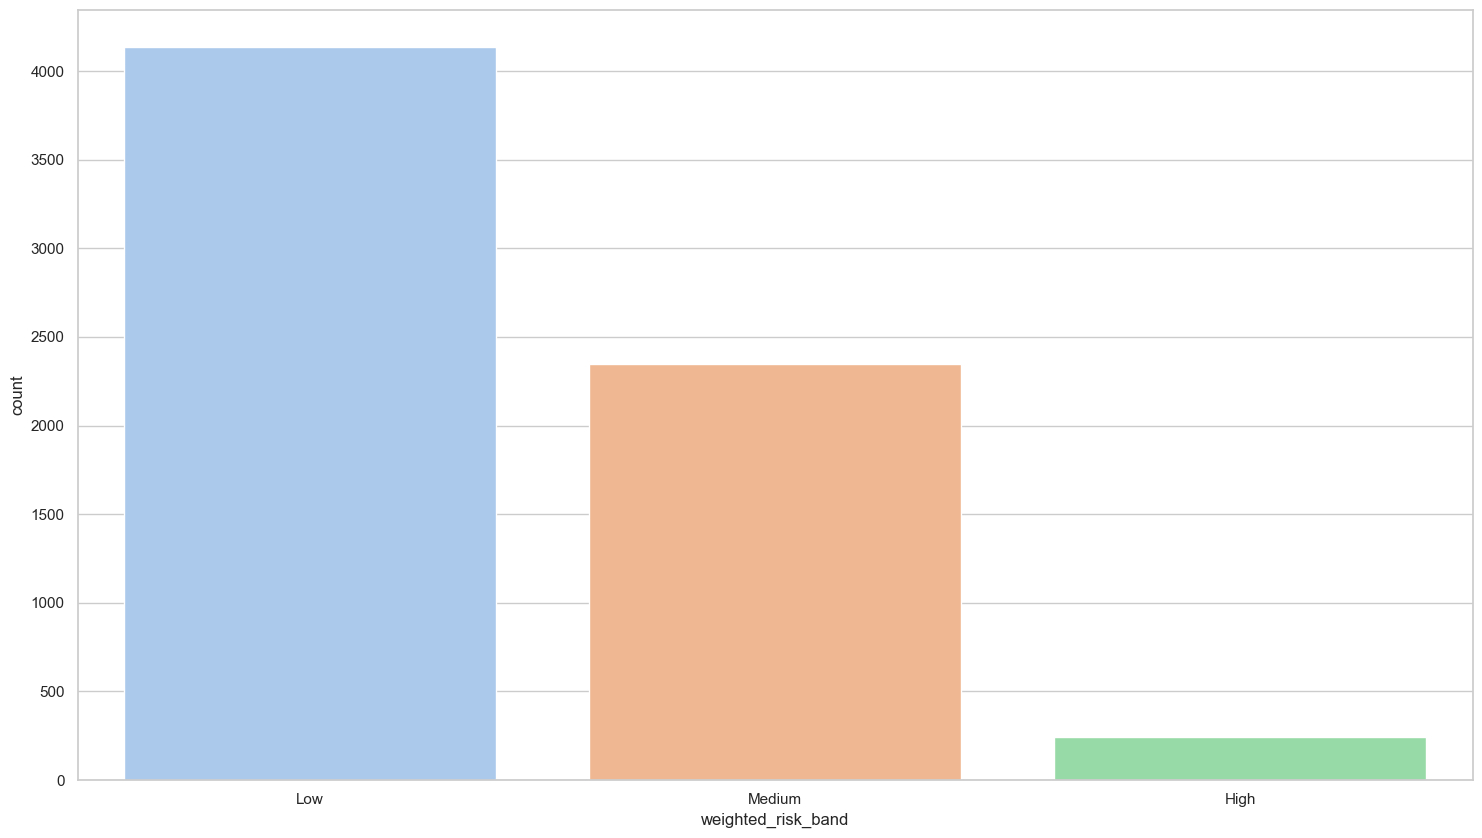

In [113]:
#visualising the new weighted risk bands

plt.figure(figsize = (18, 10))
sns.set_palette("pastel") #setting color and hue for differently colored bars, so we can observe the segments more easily.
sns.countplot(x=df['weighted_risk_band'], hue=df['weighted_risk_band'])

plt.show()

_More varied distribution_

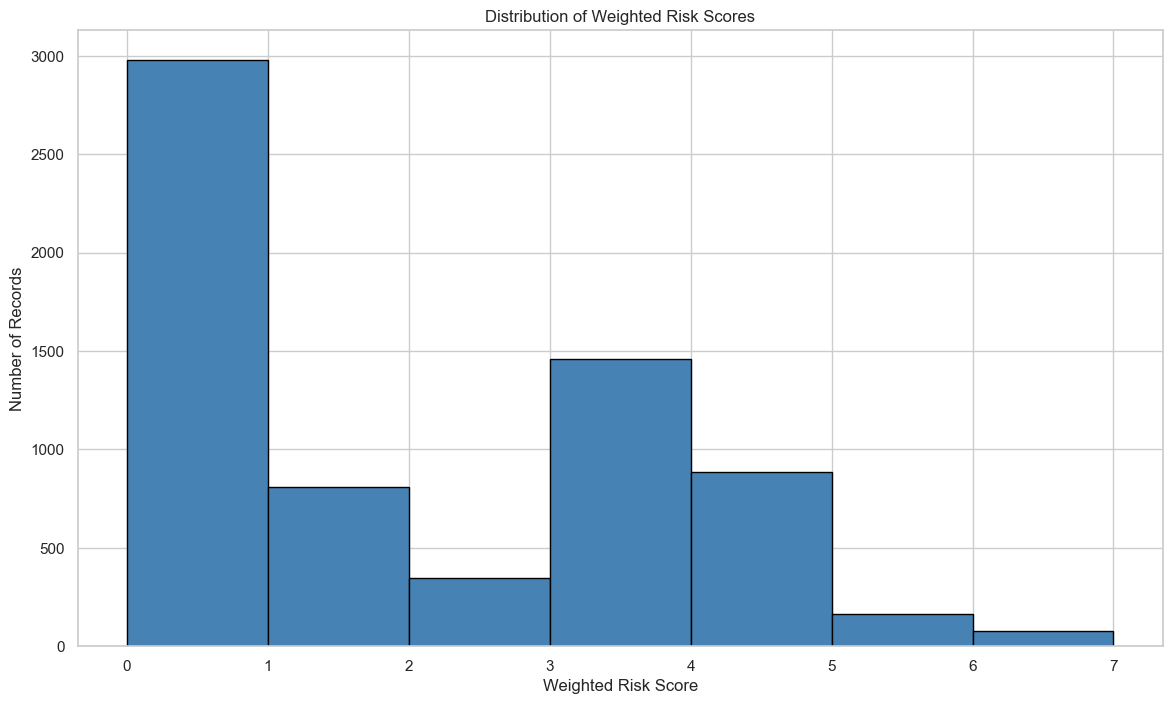

In [118]:
#checking the distribution of the weighted risk scores.
plt.hist(df['weighted_risk_score'], bins=range(0, 8), color='steelblue', edgecolor='black')
plt.title("Distribution of Weighted Risk Scores")
plt.xlabel("Weighted Risk Score")
plt.ylabel("Number of Records")
plt.grid(True)
plt.show()

#### MODELLING

In [120]:
# encoding the risk band for classification (Low=0, Medium=1, High=2)
label_encoder = LabelEncoder()
df['encoded_weighted_risk_band'] = label_encoder.fit_transform(df['weighted_risk_band'])

# defining input features and target variable
features = ['temperature_c', 'ph', 'free_chlorine_mgL', 'flow_rate_lpm']
X = df[features]
y = df['encoded_weighted_risk_band']

# splitting data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# training the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# predicting on the test set
y_pred = rf_model.predict(X_test)

# generating classification report
print(classification_report(
    y_test, y_pred, target_names=label_encoder.classes_)
)

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        49
         Low       1.00      1.00      1.00       827
      Medium       1.00      1.00      1.00       470

    accuracy                           1.00      1346
   macro avg       1.00      1.00      1.00      1346
weighted avg       1.00      1.00      1.00      1346



In [132]:
#plotting confusion matrix
def display_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('confusion matrix')
    plt.xlabel('predicted')
    plt.ylabel('actual')
    plt.show()

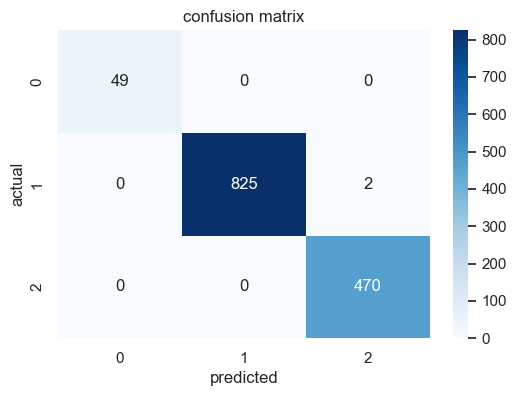

In [133]:
#random forest model confusion matrix
display_confusion_matrix(y_test, y_pred)

#### SHAP for more insight.

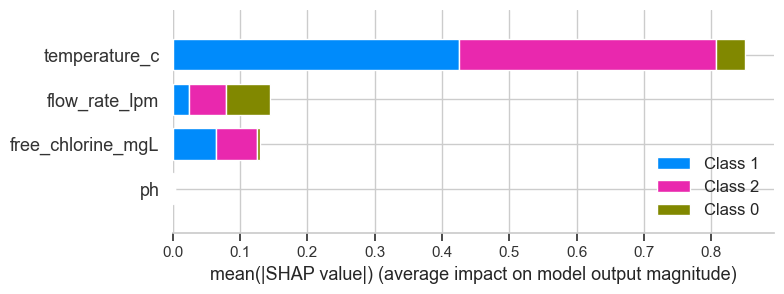

In [122]:
# Initializing SHAP explainer for tree-based model
explainer = shap.TreeExplainer(rf_model)

# Calculating SHAP values for test set
shap_values = explainer.shap_values(X_test)

# Visualizing feature importance across all predictions
shap.summary_plot(
    shap_values,
    features=X_test,
    feature_names=features,
    plot_type="bar"
)

In [126]:
# Showing top 10 risky records sorted by weighted score
df.sort_values(by='weighted_risk_score', ascending=False)[
    ['station_id', 'timestamp', 'temperature_c', 'free_chlorine_mgL', 'flow_rate_lpm', 'weighted_risk_score', 'weighted_risk_band']
].head(10)

,station_id,timestamp,temperature_c,free_chlorine_mgL,flow_rate_lpm,weighted_risk_score,weighted_risk_band
3985,STN006,2024-07-08 11:00:00,26.347147,0.131084,0.0,6,High
6377,STN010,2024-04-08 08:00:00,43.939719,0.186944,0.0,6,High
5923,STN009,2024-06-08 14:45:00,26.225556,0.075190,0.0,6,High
5201,STN008,2024-06-08 02:30:00,38.435826,0.134449,0.0,6,High
5807,STN009,2024-05-08 09:45:00,27.041502,0.182257,0.0,6,High
5202,STN008,2024-06-08 02:45:00,30.634724,0.044800,0.0,6,High
4939,STN008,2024-03-08 09:00:00,44.259183,0.087437,0.0,6,High
4143,STN007,2024-02-08 02:15:00,20.823199,0.155476,0.0,6,High
5912,STN009,2024-06-08 12:00:00,21.581936,0.082200,0.0,6,High
3980,STN006,2024-07-08 09:45:00,20.882371,0.189912,0.0,6,High


#### From the above, station9 is one of the most frequent, so selecting it to look into more. 

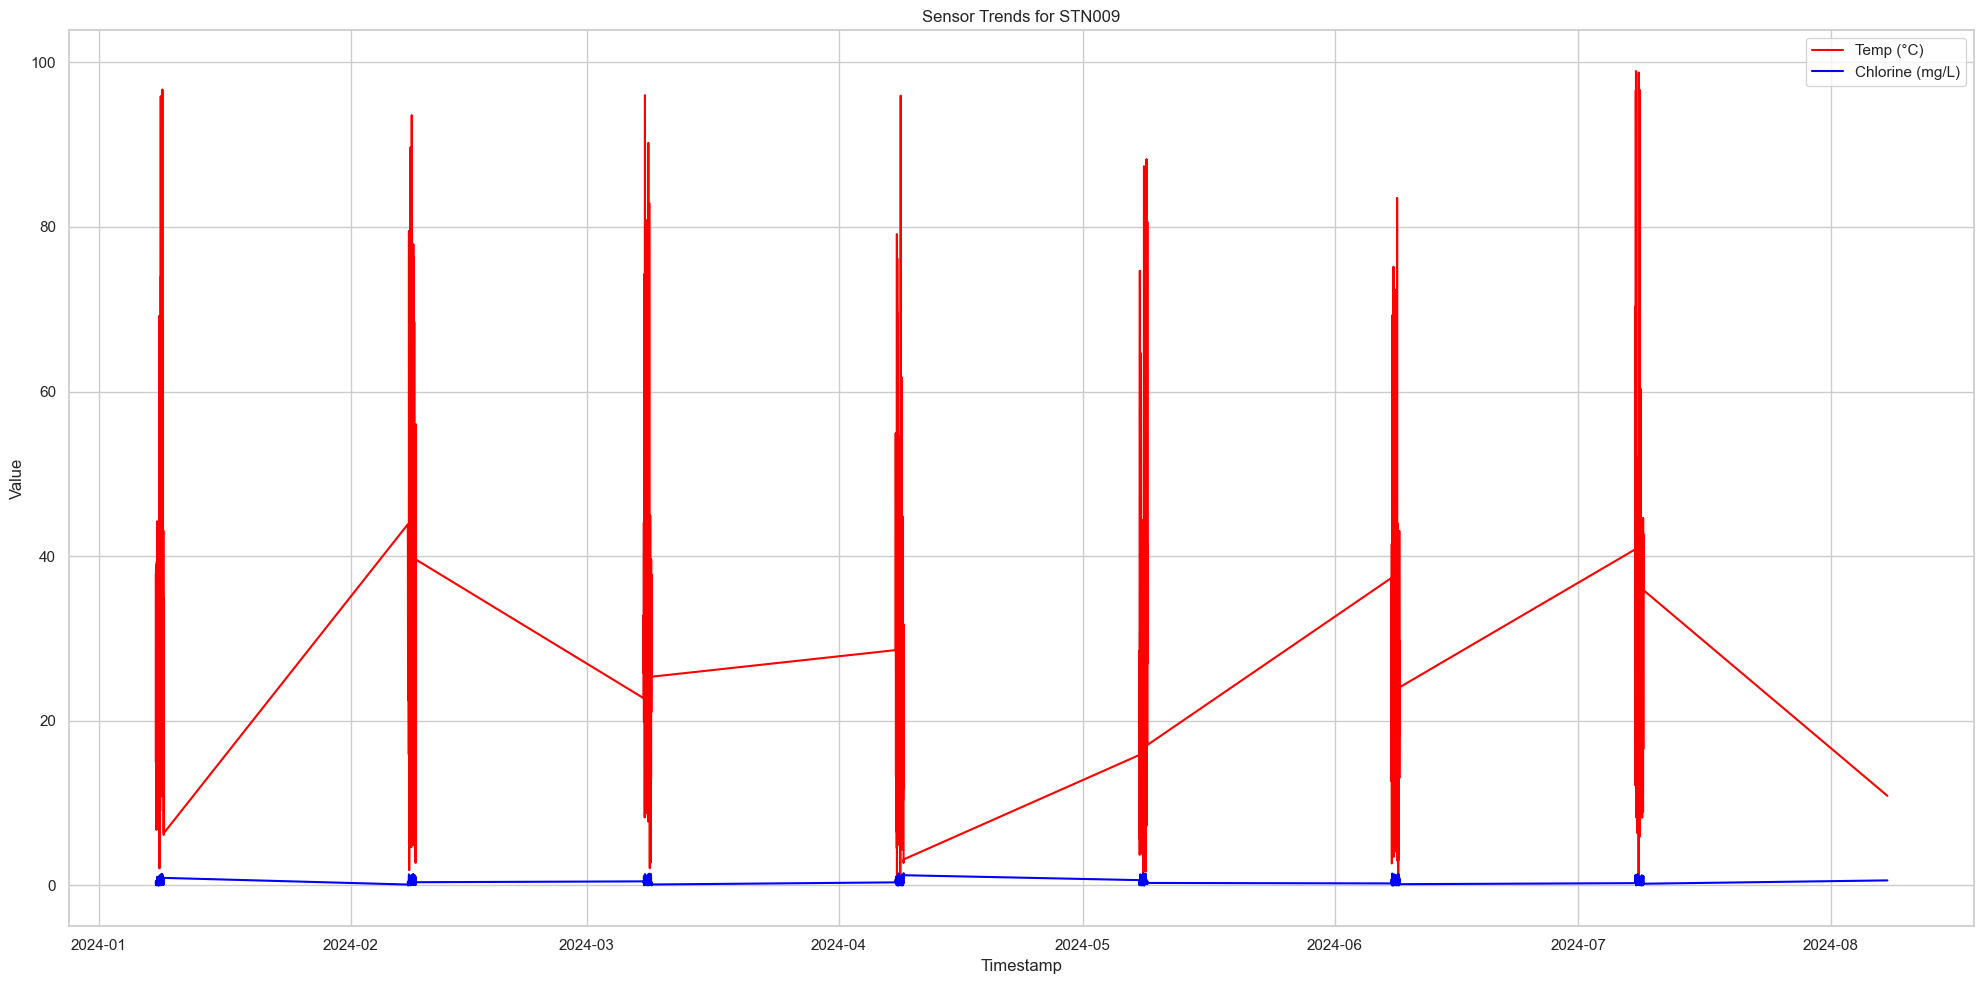

In [130]:
# Selecting station from dataset
selected_site = df['station_id'].unique()[0]

# Filtering and sorting data for that site
station_df = df[df['station_id'] == 'STN009'].sort_values('timestamp')

# Ensuring timestamp is datetime type
station_df['timestamp'] = pd.to_datetime(station_df['timestamp'])

# Plotting temperature and chlorine levels over time
plt.figure(figsize=(20, 10))
plt.plot(station_df['timestamp'], station_df['temperature_c'], label='Temp (°C)', color='red')
plt.plot(station_df['timestamp'], station_df['free_chlorine_mgL'], label='Chlorine (mg/L)', color='blue')
plt.title(f'Sensor Trends for STN009')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

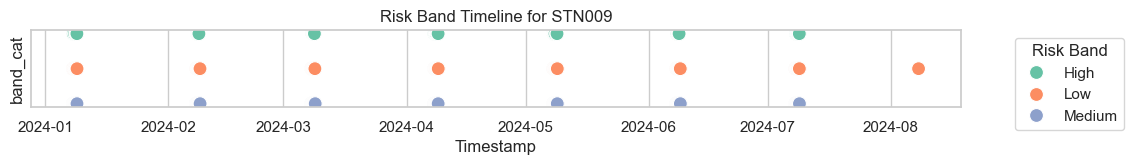

In [131]:
# setting up categorical band for coloring
station_df['band_cat'] = station_df['weighted_risk_band'].astype('category')

# plotting band timeline
plt.figure(figsize=(12, 1))
sns.scatterplot(x='timestamp', y='band_cat', hue='band_cat', data=station_df, palette='Set2', s=100)
plt.title(f'Risk Band Timeline for STN009')
plt.xlabel('Timestamp')
plt.yticks([])
plt.legend(title='Risk Band', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()